In [1]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Annotated
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_huggingface import HuggingFaceEndpoint, ChatHuggingFace
from langchain_core.messages import BaseMessage, HumanMessage, AIMessage
from langgraph.graph.message import add_messages
from dotenv import load_dotenv
from langgraph.prebuilt import ToolNode, tools_condition
from langchain_community.tools import DuckDuckGoSearchRun
from langchain_core.tools import tool

import requests
import random
import os

In [2]:
load_dotenv()
os.environ['LANGCHAIN_PROJECT'] = 'tools'

In [ ]:
import os
from langchain_mistralai import ChatMistralAI

os.environ["MISTRAL_API_KEY"] = "hdl7dvGQzeEhwH4wgf8Vkj8ASAQzMS7I"  # Get from https://mistral.ai

llm = ChatMistralAI(model="mistral-large-latest")  # Or "open-mistral-nemo", etc.

In [4]:
llm.invoke("What is ai?")

AIMessage(content='**Artificial Intelligence (AI)** refers to the simulation of human intelligence in machines, enabling them to perform tasks that typically require human-like thinking, such as learning, reasoning, problem-solving, perception, and decision-making.\n\n### **Key Aspects of AI:**\n1. **Machine Learning (ML)** – A subset of AI where systems learn from data without explicit programming. Examples:\n   - **Supervised Learning** (e.g., spam detection)\n   - **Unsupervised Learning** (e.g., customer segmentation)\n   - **Reinforcement Learning** (e.g., self-driving cars)\n\n2. **Deep Learning (DL)** – A type of ML using neural networks with many layers (e.g., image recognition, natural language processing).\n\n3. **Natural Language Processing (NLP)** – Enables machines to understand and generate human language (e.g., chatbots, translation).\n\n4. **Computer Vision** – Allows machines to interpret visual data (e.g., facial recognition, medical imaging).\n\n5. **Robotics & Autom

In [5]:
API_KEY = 'IZIVKJLWUX19OKGR'
# tools 
# There are 2 types of tools in langgraph
# 1) Prebuilt   2) Custom
# DuckDuckGoSearch is prebuilt tool
search_tool = DuckDuckGoSearchRun(region='us-en')

@tool
def calculator(first_num: float, second_num: float, operation: str) -> dict:
    """
    Perform a basic airthematic operation on two numbers.
    Supported operations are: add, sub, mul, div
    """
    try:
        if operation == 'add':
            result = first_num + second_num
        elif operation == 'sub':
            result = first_num - second_num
        elif operation == 'mul':
            result = first_num * second_num
        elif operation == 'div':
            if second_num == 0:
                return {'error': 'Division by zero is not allowed'}
            result = first_num/second_num
        else:
            return {'error':f'Unsupported operations {operation}'}
        
        return {'first_num':first_num, 'second_num':second_num, 'result':result}
    except Exception as e:
        return {"error": str(e)}

    

@tool
def get_stock_price(symbol: str) -> dict:
    """
    Fetch latest stock price for a given symbol (e.g. 'AAPL', 'TSLA') 
    using Alpha Vantage with API key in the URL.
    """
    url = f"https://www.alphavantage.co/query?function=GLOBAL_QUOTE&symbol={symbol}&apikey={API_KEY}"
    r = requests.get(url)
    return r.json()
        

In [6]:
# makeing tool list
tools = [get_stock_price, search_tool, calculator]

# make the llm tool aware
llm_with_tools = llm.bind_tools(tools)

In [7]:
class ChatState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]

In [8]:
# graph nodes
def chat_node(state: ChatState):
    """
    LLM node that may answer or request a tool call
    """
    messages = state['messages']
    response = llm_with_tools.invoke(messages)
    return {'messages':[response]}


# Tool Node is an automatic tool execution node in langgraph.
tool_node = ToolNode(tools=tools)

In [9]:
# graph structure
graph = StateGraph(ChatState)
graph.add_node('chat_node', chat_node)
graph.add_node('tools', tool_node)

In [10]:
graph.add_edge(START, 'chat_node')
# A Tools Condition is a function or rule attached to a Tool Node that decides:
# Whether a particular tool should be executed or skipped for a given input/state.
# It is pre-built by langgraph
graph.add_conditional_edges('chat_node', tools_condition)

In [11]:
workflow = graph.compile()

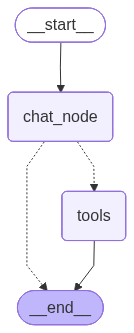

In [12]:
workflow

In [13]:
response = workflow.invoke({"messages":[HumanMessage(content="Hello")]})
print(response['messages'][-1].content)

Hello! How can I assist you today? 😊


In [14]:
response = workflow.invoke({"messages":[HumanMessage(content="88888888*88888888=?")]})
print(response['messages'][-1].content)

{"first_num": 88888888.0, "second_num": 88888888.0, "result": 7901234409876544.0}


In [15]:
response = workflow.invoke({"messages":[HumanMessage(content="Who win the series between pakistan and australia recently played in pakista?")]})
print(response['messages'][-1].content)

icc-champions-trophy ICC Champions Trophy, 2025. icc-w-u19-t20-wc ICC Women's Under-19 T20 World Cup, 2025. icc-cwc-challenge-league-a-b ICC CWC Challenge League A and B, 2024 -26.Fixtures & Results . Read all the latest information related to Cricket, live scores,Cricket news, results , stats, videos, highlights. Find all the Cricket matches schedules at NDTV Sports. Australia Women and India Women meet in the decisive third T20I at Adelaide, with the series level. Both sides aim to clinch momentum and seal the trophy in what promises to be a high-intensity finale. Home/Colombo Weather Update: Rain Threat Over India vs Pakistan T20 World Cup 2026 Match/colombo-weather-r-premadasa-stadium.September 18, 2024 . WhatsApp Introducing New Security Checkup Feature Soon. Pakistan . Panama. Paraguay. Australia FFA Cup Qualifiers South Australia Football Season


In [16]:
response = workflow.invoke({"messages":[HumanMessage(content="What is the stock price of Tesla?")]})
print(response['messages'][-1].content)

{"Global Quote": {"01. symbol": "TSLA", "02. open": "408.3000", "03. high": "414.7000", "04. low": "405.5000", "05. price": "411.8200", "06. volume": "57912225", "07. latest trading day": "2026-02-20", "08. previous close": "411.7100", "09. change": "0.1100", "10. change percent": "0.0267%"}}


Problem in this workflow is, that its output is not organized, and what if user ask a question which need to use tool more than 1 time

In [17]:
response = workflow.invoke({"messages":[HumanMessage(content="Which is the largest company in Pakistan, and what its stock prize is?")]})
print(response['messages'][-1].content)

Oil and Gas Development Company (OGDC) has remained Pakistan's most valuable company since 2023. In 2025, the company ranked at the top with a market cap of 4.3 billion dollars. The second most valuable is United Bank Limited (UBL), with a market cap of 3.5 billion dollars. A total of five listed companies have a market cap ranging from $2.05 billion to $3.46 billion as of July 7, 2025. The Pakistan Stock Exchange (PSX) has hit record highs in recent weeks with its benchmark KSE-100 Index sitting pretty at over 130,000. It hit an all-time high of 131,949.07 on Friday, with analysts attributing the market's record-breaking trajectory to aggressive institutional ... KARACHI - Pakistan's corporate landscape continues to be dominated by energy and banking sectors with state run Oil & Gas Development Company (OGDC) raking in top position as country's largest company by market capitalization at $4.25 billion. The financial sector also commands a major share of market , with UBL, Meezan Bank,

## New Workflow

In [18]:
# graph structure
newGraph = StateGraph(ChatState)
newGraph.add_node('chat_node', chat_node)
newGraph.add_node('tools', tool_node)

In [19]:
newGraph.add_edge(START, 'chat_node')
newGraph.add_conditional_edges('chat_node', tools_condition)
newGraph.add_edge('tools', 'chat_node')

In [20]:
newWorkflow = newGraph.compile()

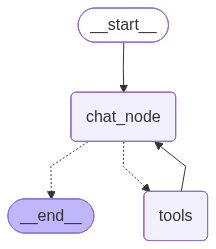

In [21]:
newWorkflow

In [22]:
response = newWorkflow.invoke({"messages":[HumanMessage(content="what is 88888888*88888888=?")]})
print(response['messages'][-1].content)

The result of \( 88888888 \times 88888888 \) is **7,901,234,409,876,544**.


In [23]:
response = newWorkflow.invoke({"messages":[HumanMessage(content="Which is the largest company in Pakistan, and what its stock prize is?")]})
print(response['messages'][-1].content)

It seems I was unable to fetch the stock prices for the largest companies in Pakistan directly. However, based on the latest data:

### **Largest Companies in Pakistan by Market Capitalization (2025)**
1. **Oil & Gas Development Company Limited (OGDC)** – Market capitalization of approximately **$3.35 billion**.
2. **United Bank Limited (UBL)** – Market capitalization of approximately **$4 billion** (as of January 2026, UBL became the first company in Pakistan to join the **four-billion-dollar club** with a market cap of **Rs 1.28 trillion**).

### **Stock Price Update**
Since I couldn't fetch the real-time stock prices, I recommend checking the latest stock prices for:
- **OGDC** on the [Pakistan Stock Exchange (PSX)](https://www.psx.com.pk/) or financial platforms like **Yahoo Finance** or **TradingView**.
- **UBL** similarly on the PSX or other financial platforms.

Would you like me to search for any additional details?


In [24]:
response = newWorkflow.invoke({"messages":[HumanMessage(content="Who win the last match played between Pakistan and Australia?")]})
print(response['messages'][-1].content)

The **last match** played between **Pakistan and Australia** was a **T20I** on **February 1, 2026**, where **Pakistan won convincingly** by a large margin of runs. This victory completed a **clean sweep** for Pakistan over Australia in the T20I series.

Australia was bowled out for just **96 runs**, and Pakistan dominated with their spin attack. This was Australia's biggest-ever T20I defeat in terms of runs.


In [25]:
response = newWorkflow.invoke({"messages":[HumanMessage(content="What is the stock price of Tesla?")]})
print(response['messages'][-1].content)

The current stock price of **Tesla (TSLA)** is **\$411.82** as of the latest trading day (2026-02-20).
